# APEX Moto Sales Analysis — Data Cleaning

This notebook loads the raw APEX Moto sales export (three yearly CSVs plus
dimension/lookup files), merges everything into clean, analysis-ready
DataFrames, and writes the cleaned output to `Dataset/Cleaned Data/`.

**Pipeline**
1. Load raw files
2. Merge 2020 / 2021 / 2022 sales into one fact table
3. Null / missing-value audit
4. Duplicate checking
5. Data type conversion
6. Column renaming for clarity
7. Handle known data-quality issues (junk rows, encoding, missing values)
8. Outlier detection
9. Feature engineering
10. Build the master (denormalized) analysis table
11. Final null + summary report
12. Export cleaned data


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import os

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

RAW_PATH = '../Dataset/Raw Data/'
CLEAN_PATH = '../Dataset/Cleaned Data/'
os.makedirs(CLEAN_PATH, exist_ok=True)


## 2. Load Raw Data

The sales fact data is split across three yearly exports. The `Customer
Lookup` file is **not UTF-8** — it's Windows-1252 (Latin-1) encoded — so it
must be read with `encoding='latin1'` or pandas will throw a
`UnicodeDecodeError`.

In [2]:
sales_2020 = pd.read_csv(RAW_PATH + 'ApexMoto_Sales_Data_2020.csv')
sales_2021 = pd.read_csv(RAW_PATH + 'ApexMoto_Sales_Data_2021.csv')
sales_2022 = pd.read_csv(RAW_PATH + 'ApexMoto_Sales_Data_2022.csv')

# Tag each with its source year before merging (useful for later QA)
sales_2020['SourceYear'] = 2020
sales_2021['SourceYear'] = 2021
sales_2022['SourceYear'] = 2022

print('2020:', sales_2020.shape)
print('2021:', sales_2021.shape)
print('2022:', sales_2022.shape)


2020: (2630, 9)
2021: (23935, 9)
2022: (29481, 9)


In [3]:
customer_df   = pd.read_csv(RAW_PATH + 'ApexMoto_Customer_Lookup.csv', encoding='latin1')
product_df    = pd.read_csv(RAW_PATH + 'ApexMoto_Product_Lookup.csv', encoding='latin1')
category_df   = pd.read_csv(RAW_PATH + 'ApexMoto_Product_Categories_Lookup.csv')
subcat_df     = pd.read_csv(RAW_PATH + 'ApexMoto_Product_Subcategories_Lookup.csv')
territory_df  = pd.read_csv(RAW_PATH + 'ApexMoto_Territory_Lookup.csv')
calendar_df   = pd.read_csv(RAW_PATH + 'ApexMoto_Calendar_Lookup.csv')
returns_df    = pd.read_csv(RAW_PATH + 'ApexMoto_Returns_Data.csv')

print('customer_df:', customer_df.shape)
print('product_df:', product_df.shape)
print('category_df:', category_df.shape)
print('subcat_df:', subcat_df.shape)
print('territory_df:', territory_df.shape)
print('calendar_df:', calendar_df.shape)
print('returns_df:', returns_df.shape)


customer_df: (18154, 13)
product_df: (293, 11)
category_df: (4, 2)
subcat_df: (37, 3)
territory_df: (10, 4)
calendar_df: (912, 1)
returns_df: (1809, 4)


## 3. Merge the Three Yearly Sales Files into One Fact Table

In [4]:
sales_df = pd.concat([sales_2020, sales_2021, sales_2022], ignore_index=True)
print('Combined sales_df shape:', sales_df.shape)
sales_df.head()


Combined sales_df shape: (56046, 9)


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,OrderQuantity,SourceYear
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,2020
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,2020
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,2020
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,2020
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,2020


## 4. Initial Data Quality Audit

Before touching anything, let's look at structure, dtypes, and nulls
across every table so we know exactly what needs fixing.

In [5]:
sales_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 56046 entries, 0 to 56045
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   OrderDate      56046 non-null  str  
 1   StockDate      56046 non-null  str  
 2   OrderNumber    56046 non-null  str  
 3   ProductKey     56046 non-null  int64
 4   CustomerKey    56046 non-null  int64
 5   TerritoryKey   56046 non-null  int64
 6   OrderLineItem  56046 non-null  int64
 7   OrderQuantity  56046 non-null  int64
 8   SourceYear     56046 non-null  int64
dtypes: int64(6), str(3)
memory usage: 3.8 MB


In [6]:
def null_report(df, name):
    n = df.isnull().sum()
    pct = (n / len(df) * 100).round(2)
    rep = pd.DataFrame({'nulls': n, 'pct_null': pct})
    rep = rep[rep['nulls'] > 0].sort_values('nulls', ascending=False)
    if rep.empty:
        print(f'[{name}] No nulls found.')
    else:
        print(f'[{name}] Null report:')
        display(rep)

for name, df in [('sales_df', sales_df), ('customer_df', customer_df),
                  ('product_df', product_df), ('category_df', category_df),
                  ('subcat_df', subcat_df), ('territory_df', territory_df),
                  ('calendar_df', calendar_df), ('returns_df', returns_df)]:
    null_report(df, name)


[sales_df] No nulls found.
[customer_df] Null report:


,nulls,pct_null
Gender,136,0.75
Prefix,133,0.73
LastName,6,0.03
MaritalStatus,6,0.03
FirstName,6,0.03
TotalChildren,6,0.03
EducationLevel,6,0.03
EmailAddress,6,0.03
AnnualIncome,6,0.03
Occupation,6,0.03


[product_df] Null report:


,nulls,pct_null
ProductColor,50,17.06


[category_df] No nulls found.
[subcat_df] No nulls found.
[territory_df] No nulls found.
[calendar_df] No nulls found.
[returns_df] No nulls found.


**Findings:**
- `sales_df`, `category_df`, `subcat_df`, `territory_df`, `calendar_df`, `returns_df` are clean — no nulls.
- `customer_df` has nulls in several columns, largely coming from a handful of corrupted rows at the very end of the file (see below).
- `product_df` has 50 nulls in `ProductColor`.

## 5. Duplicate Checking

In [7]:
print('Fully duplicated rows in sales_df:', sales_df.duplicated().sum())
print('Duplicate (OrderNumber, ProductKey, OrderLineItem):',
      sales_df.duplicated(subset=['OrderNumber', 'ProductKey', 'OrderLineItem']).sum())
print('Duplicate CustomerKey (raw):', customer_df['CustomerKey'].duplicated().sum())
print('Duplicate ProductKey:', product_df['ProductKey'].duplicated().sum())


Fully duplicated rows in sales_df: 0
Duplicate (OrderNumber, ProductKey, OrderLineItem): 0
Duplicate CustomerKey (raw): 2
Duplicate ProductKey: 0


## 6. Fixing `customer_df` — Corrupted / Footer Rows

Inspecting the tail of the raw file reveals junk rows that don't belong in
the dataset at all: a blank row and what look like **export-tool footer
metadata** (`"Export date ..."`, `"Source AW_Cust_Master"`), plus 3 rows
where `CustomerKey` was corrupted to the literal string `'30---'`. These
happen when an export job appends a trailer to the CSV — a common
real-world data issue.

In [8]:
# Rows where CustomerKey can't be parsed as a number are the junk rows
junk_mask = pd.to_numeric(customer_df['CustomerKey'], errors='coerce').isna()
print(f'Junk rows found: {junk_mask.sum()}')
customer_df[junk_mask]


Junk rows found: 6


,CustomerKey,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome,TotalChildren,EducationLevel,Occupation,HomeOwner
18148,30---,m,NaN,NaN,1900-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18149,30---,m,NaN,NaN,1900-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18150,30---,m,NaN,NaN,1900-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18152,Export date 20230101 14:59:17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18153,Source AW_Cust_Master,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
customer_df = customer_df[~junk_mask].copy()
customer_df['CustomerKey'] = customer_df['CustomerKey'].astype(int)
print('customer_df shape after dropping junk rows:', customer_df.shape)


customer_df shape after dropping junk rows: (18148, 13)


## 7. Data Type Conversion

In [10]:
sales_df['OrderDate'] = pd.to_datetime(sales_df['OrderDate'])
sales_df['StockDate'] = pd.to_datetime(sales_df['StockDate'])
customer_df['BirthDate'] = pd.to_datetime(customer_df['BirthDate'])
calendar_df['Date'] = pd.to_datetime(calendar_df['Date'])
returns_df['ReturnDate'] = pd.to_datetime(returns_df['ReturnDate'])

sales_df[['ProductKey', 'CustomerKey', 'TerritoryKey', 'OrderLineItem', 'OrderQuantity']] = \
    sales_df[['ProductKey', 'CustomerKey', 'TerritoryKey', 'OrderLineItem', 'OrderQuantity']].astype(int)

customer_df['AnnualIncome'] = customer_df['AnnualIncome'].astype(float)
customer_df['TotalChildren'] = customer_df['TotalChildren'].astype(int)

product_df[['ProductCost', 'ProductPrice']] = product_df[['ProductCost', 'ProductPrice']].astype(float)

print('Dtypes converted successfully.')
sales_df.dtypes


Dtypes converted successfully.

OrderDate        datetime64[us]
StockDate        datetime64[us]
OrderNumber                 str
ProductKey                int64
CustomerKey               int64
TerritoryKey              int64
OrderLineItem             int64
OrderQuantity             int64
SourceYear                int64
dtype: object

## 8. Handle Remaining Missing Values

In [11]:
# Remaining nulls in customer_df are genuine missing survey responses,
# not corrupted rows — recode rather than drop, so we don't lose the
# customer's transaction history.
customer_df['Gender'] = customer_df['Gender'].fillna('U')             # Unknown
customer_df['MaritalStatus'] = customer_df['MaritalStatus'].fillna('U')
customer_df['HomeOwner'] = customer_df['HomeOwner'].fillna('U')
customer_df['EducationLevel'] = customer_df['EducationLevel'].fillna('Unknown')
customer_df['Occupation'] = customer_df['Occupation'].fillna('Unknown')
# Prefix is not used analytically -- safe to leave null / drop later

product_df['ProductColor'] = product_df['ProductColor'].fillna('Unknown')

null_report(customer_df, 'customer_df (post-fill)')
null_report(product_df, 'product_df (post-fill)')


[customer_df (post-fill)] Null report:


,nulls,pct_null
Prefix,130,0.72


[product_df (post-fill)] No nulls found.


## 9. Rename Columns for Clarity & Consistency

In [12]:
sales_df = sales_df.rename(columns={
    'OrderQuantity': 'Quantity'
})

territory_df = territory_df.rename(columns={
    'SalesTerritoryKey': 'TerritoryKey'
})

customer_df = customer_df.rename(columns={
    'AnnualIncome': 'AnnualIncome_USD'
})

print('Columns renamed.')


Columns renamed.

## 10. Outlier Detection (IQR method)

Checking `AnnualIncome` and order `Quantity` for outliers using the
1.5×IQR rule. This dataset caps `Quantity` at small values (1-3 units per
line), so we mainly expect to see outliers on the income side.

AnnualIncome IQR bounds: [-30,000, 130,000]
Outlier customers: 300 (1.65%)


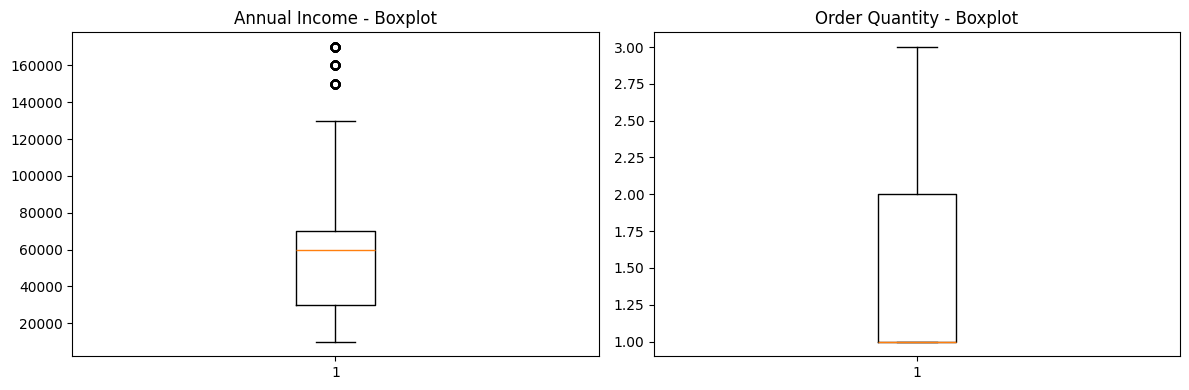

In [13]:
import matplotlib.pyplot as plt

def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series[(series < lower) | (series > upper)], lower, upper

income_outliers, low, high = iqr_outliers(customer_df['AnnualIncome_USD'])
print(f'AnnualIncome IQR bounds: [{low:,.0f}, {high:,.0f}]')
print(f'Outlier customers: {len(income_outliers)} ({len(income_outliers)/len(customer_df)*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(customer_df['AnnualIncome_USD'])
axes[0].set_title('Annual Income - Boxplot')
axes[1].boxplot(sales_df['Quantity'])
axes[1].set_title('Order Quantity - Boxplot')
plt.tight_layout()
plt.show()


**Decision:** High-income customers are a legitimate, expected part of the
population (not data-entry errors), so we keep them rather than remove or
cap them — removing real customers would bias revenue-per-customer
analysis. We simply flag them via `IncomeBand` in the feature engineering
step below.

## 11. Feature Engineering

In [14]:
# --- Customer features ---
customer_df['FirstName'] = customer_df['FirstName'].str.strip().str.title()
customer_df['LastName'] = customer_df['LastName'].str.strip().str.title()
customer_df['FullName'] = customer_df['FirstName'] + ' ' + customer_df['LastName']

snapshot_date = sales_df['OrderDate'].max()
customer_df['Age'] = ((snapshot_date - customer_df['BirthDate']).dt.days / 365.25).astype(int)

def age_band(age):
    if age < 25: return 'Under 25'
    elif age < 35: return '25-34'
    elif age < 45: return '35-44'
    elif age < 55: return '45-54'
    elif age < 65: return '55-64'
    else: return '65+'
customer_df['AgeBand'] = customer_df['Age'].apply(age_band)

def income_band(income):
    if income < 40000: return 'Low (<40K)'
    elif income <= 80000: return 'Mid (40K-80K)'
    elif income <= 120000: return 'High (80K-120K)'
    else: return 'Premium (>120K)'
customer_df['IncomeBand'] = customer_df['AnnualIncome_USD'].apply(income_band)

# --- Product features ---
product_df['ProductMargin'] = product_df['ProductPrice'] - product_df['ProductCost']
product_df['ProductMarginPct'] = (product_df['ProductMargin'] / product_df['ProductPrice'] * 100).round(2)

# --- Sales features ---
sales_df['OrderYear'] = sales_df['OrderDate'].dt.year
sales_df['OrderMonth'] = sales_df['OrderDate'].dt.month
sales_df['OrderMonthName'] = sales_df['OrderDate'].dt.strftime('%b')
sales_df['OrderYearMonth'] = sales_df['OrderDate'].dt.to_period('M').astype(str)
sales_df['IsWeekend'] = sales_df['OrderDate'].dt.dayofweek >= 5

print('Feature engineering complete.')
customer_df[['CustomerKey', 'FullName', 'Age', 'AgeBand', 'IncomeBand']].head()


Feature engineering complete.


,CustomerKey,FullName,Age,AgeBand,IncomeBand
0,11000,Jon Yang,56,55-64,High (80K-120K)
1,11001,Eugene Huang,57,55-64,Mid (40K-80K)
2,11002,Ruben Torres,56,55-64,Mid (40K-80K)
3,11003,Christy Zhu,54,45-54,Mid (40K-80K)
4,11004,Elizabeth Johnson,53,45-54,Mid (40K-80K)


## 12. Build Product Dimension & Master Analysis Table

In [15]:
product_full = (product_df
    .merge(subcat_df, on='ProductSubcategoryKey', how='left')
    .merge(category_df, on='ProductCategoryKey', how='left')
)
print('product_full shape:', product_full.shape)

master_df = (sales_df
    .merge(product_full, on='ProductKey', how='left')
    .merge(customer_df, on='CustomerKey', how='left')
    .merge(territory_df, on='TerritoryKey', how='left')
)

master_df['Revenue'] = master_df['Quantity'] * master_df['ProductPrice']
master_df['COGS'] = master_df['Quantity'] * master_df['ProductCost']
master_df['Profit'] = master_df['Revenue'] - master_df['COGS']

print('master_df shape:', master_df.shape)
master_df.head()


product_full shape: (293, 16)


master_df shape: (56046, 51)


,OrderDate,StockDate,OrderNumber,ProductKey,CustomerKey,TerritoryKey,OrderLineItem,Quantity,SourceYear,OrderYear,OrderMonth,OrderMonthName,OrderYearMonth,IsWeekend,ProductSubcategoryKey,ProductSKU,ProductName,ModelName,ProductDescription,ProductColor,ProductSize,ProductStyle,ProductCost,ProductPrice,ProductMargin,...,SubcategoryName,ProductCategoryKey,CategoryName,Prefix,FirstName,LastName,BirthDate,MaritalStatus,Gender,EmailAddress,AnnualIncome_USD,TotalChildren,EducationLevel,Occupation,HomeOwner,FullName,Age,AgeBand,IncomeBand,Region,Country,Continent,Revenue,COGS,Profit
0,2020-01-01,2019-09-21,SO45080,332,14657,1,1,1,2020,2020,1,Jan,2020-01,False,2,BK-R50B-58,"Road-650 Black, 58",Road-650,Value-priced bike with many features of our to...,Black,58,U,413.15,699.10,285.95,...,Road Bikes,1,Bikes,MR.,John,Thomas,1958-11-11,M,M,john48@adventure-works.com,"80,000.00",1,Partial College,Skilled Manual,N,John Thomas,63,55-64,Mid (40K-80K),Northwest,United States,North America,699.10,413.15,285.95
1,2020-01-01,2019-12-05,SO45079,312,29255,4,1,1,2020,2020,1,Jan,2020-01,False,2,BK-R93R-48,"Road-150 Red, 48",Road-150,This bike is ridden by race winners. Developed...,Red,48,U,"2,171.29","3,578.27","1,406.98",...,Road Bikes,1,Bikes,MR.,Kyle,Washington,1955-04-11,S,M,kyle8@adventure-works.com,"80,000.00",3,Partial College,Professional,N,Kyle Washington,67,65+,Mid (40K-80K),Southwest,United States,North America,"3,578.27","2,171.29","1,406.98"
2,2020-01-01,2019-10-29,SO45082,350,11455,9,1,1,2020,2020,1,Jan,2020-01,False,1,BK-M82B-44,"Mountain-100 Black, 44",Mountain-100,Top-of-the-line competition mountain bike. Per...,Black,44,U,"1,898.09","3,374.99","1,476.90",...,Mountain Bikes,1,Bikes,MR.,Ross,Sanz,1974-04-21,M,M,ross38@adventure-works.com,"100,000.00",0,High School,Management,Y,Ross Sanz,48,45-54,High (80K-120K),Australia,Australia,Pacific,"3,374.99","1,898.09","1,476.90"
3,2020-01-01,2019-11-16,SO45081,338,26782,6,1,1,2020,2020,1,Jan,2020-01,False,2,BK-R50B-44,"Road-650 Black, 44",Road-650,Value-priced bike with many features of our to...,Black,44,U,413.15,699.10,285.95,...,Road Bikes,1,Bikes,MR.,Seth,Lewis,1980-09-25,S,M,seth20@adventure-works.com,"30,000.00",0,High School,Skilled Manual,N,Seth Lewis,41,35-44,Low (<40K),Canada,Canada,North America,699.10,413.15,285.95
4,2020-01-02,2019-12-15,SO45083,312,14947,10,1,1,2020,2020,1,Jan,2020-01,False,2,BK-R93R-48,"Road-150 Red, 48",Road-150,This bike is ridden by race winners. Developed...,Red,48,U,"2,171.29","3,578.27","1,406.98",...,Road Bikes,1,Bikes,MR.,Alejandro,Chen,1965-01-11,S,M,alejandro4@adventure-works.com,"20,000.00",2,High School,Manual,Y,Alejandro Chen,57,55-64,Low (<40K),United Kingdom,United Kingdom,Europe,"3,578.27","2,171.29","1,406.98"


## 13. Final Null Report (Post-Cleaning)

In [16]:
null_report(master_df, 'master_df (final)')
null_report(customer_df, 'customer_df (final)')
null_report(product_full, 'product_full (final)')


[master_df (final)] Null report:


,nulls,pct_null
Prefix,380,0.68


[customer_df (final)] Null report:


,nulls,pct_null
Prefix,130,0.72


[product_full (final)] No nulls found.


## 14. Summary Report

In [17]:
summary = {
    'Total Sales Records': len(sales_df),
    'Date Range': f"{sales_df['OrderDate'].min().date()} to {sales_df['OrderDate'].max().date()}",
    'Unique Customers': customer_df['CustomerKey'].nunique(),
    'Unique Products': product_full['ProductKey'].nunique(),
    'Unique Orders': sales_df['OrderNumber'].nunique(),
    'Total Units Sold': int(sales_df['Quantity'].sum()),
    'Total Revenue': f"${master_df['Revenue'].sum():,.2f}",
    'Total Profit': f"${master_df['Profit'].sum():,.2f}",
    'Overall Profit Margin %': f"{master_df['Profit'].sum() / master_df['Revenue'].sum() * 100:.2f}%",
    'Total Returns (units)': int(returns_df['ReturnQuantity'].sum()),
    'Return Rate %': f"{returns_df['ReturnQuantity'].sum() / sales_df['Quantity'].sum() * 100:.2f}%",
    'Territories Covered': territory_df['TerritoryKey'].nunique(),
    'Countries Covered': territory_df['Country'].nunique(),
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
summary_df


,Metric,Value
0,Total Sales Records,56046
1,Date Range,2020-01-01 to 2022-06-30
2,Unique Customers,18148
3,Unique Products,293
4,Unique Orders,25164
5,Total Units Sold,84174
6,Total Revenue,"$24,914,586.82"
7,Total Profit,"$10,457,715.43"
8,Overall Profit Margin %,41.97%
9,Total Returns (units),1828


## 15. Export Cleaned Data

Writing cleaned, analysis-ready CSVs to `Dataset/Cleaned Data/` for use in
the EDA notebook, and to keep the SQL and Python halves of this project
consistent.

In [18]:
sales_df.to_csv(CLEAN_PATH + 'cleaned_sales.csv', index=False)
customer_df.to_csv(CLEAN_PATH + 'cleaned_customers.csv', index=False)
product_full.to_csv(CLEAN_PATH + 'cleaned_products.csv', index=False)
territory_df.to_csv(CLEAN_PATH + 'cleaned_territory.csv', index=False)
returns_df.to_csv(CLEAN_PATH + 'cleaned_returns.csv', index=False)
master_df.to_csv(CLEAN_PATH + 'master_sales_data.csv', index=False)

print('All cleaned files exported to', CLEAN_PATH)


All cleaned files exported to ../Dataset/Cleaned Data/


---
**Next notebook:** `02_EDA.ipynb` picks up from `master_sales_data.csv` /
`cleaned_customers.csv` and builds all visualizations (trend, category,
customer, geographic, Pareto/ABC, correlation, and returns analysis).